# gradient-boosted tree

In [1]:
import pandas as pd

In [2]:
from dataengineers import Dataset

In [3]:
dataset = Dataset('train')
train, test = dataset.build_train_test()

/Users/matusbolecek/repos/nitor-comp/dataengineers.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df[f'{col}_rolling_mean_{window}h'] = (
/Users/matusbolecek/repos/nitor-comp/dataengineers.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df[f'{col}_ramp_{diff}h'] = (


In [4]:
exclude = ['id', 'target', 'delivery_start', 'market', 'market_int', 'timestamp_int', 'day_of_year', 'dayofweek', 'hour']

In [5]:
features = [c for c in train.columns if c not in exclude]

In [6]:
from models import XGB

In [7]:
xg = XGB(features)

In [8]:
xg.fit(train, test)

[0]	validation_0-rmse:2.22235	validation_1-rmse:2.42815


/Users/matusbolecek/repos/nitor-comp/.venv/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [18:04:28] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:1.66090	validation_1-rmse:1.93280
[200]	validation_0-rmse:1.47996	validation_1-rmse:1.84549
[300]	validation_0-rmse:1.39471	validation_1-rmse:1.83095
[400]	validation_0-rmse:1.34113	validation_1-rmse:1.82516
[500]	validation_0-rmse:1.30202	validation_1-rmse:1.82332
[600]	validation_0-rmse:1.27058	validation_1-rmse:1.82687
[628]	validation_0-rmse:1.26116	validation_1-rmse:1.82726


In [9]:
y_vals = xg.predict(test)

In [10]:
from utils import rmse

In [11]:
rmse(test['target'], y_vals)

np.float64(49.81653230120169)

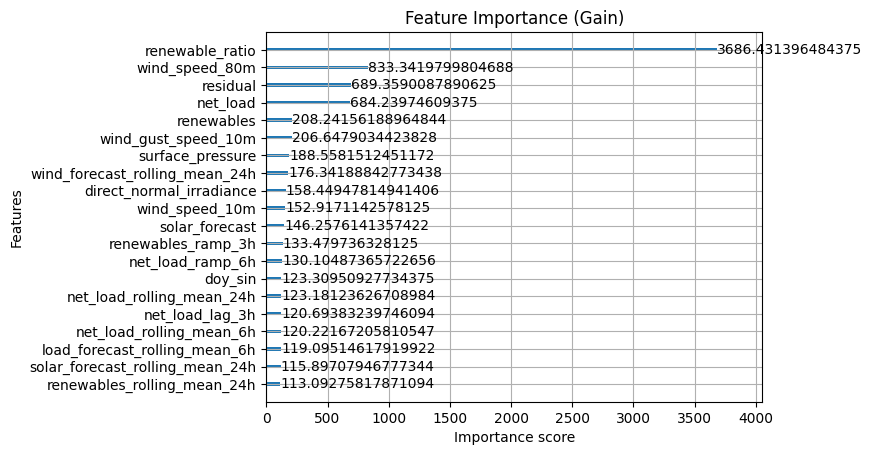

In [12]:
xg.stats()

In [13]:
ds2 = Dataset('test')

In [14]:
df_out = ds2.build_main()

/Users/matusbolecek/repos/nitor-comp/dataengineers.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df[f'{col}_rolling_mean_{window}h'] = (
/Users/matusbolecek/repos/nitor-comp/dataengineers.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df[f'{col}_ramp_{diff}h'] = (


In [15]:
y_out = xg.predict(df_out)

In [16]:
df_out['target'] = y_out

/var/folders/9p/v_hqlw5n24gdvttxlkst5c380000gn/T/ipykernel_37650/1019923952.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_out['target'] = y_out


In [17]:
df_out.head()

,id,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,precipitation_amount,visibility,...,renewables_lag_6h,renewables_lag_12h,renewables_lag_24h,renewables_lag_48h,renewables_rolling_mean_6h,renewables_rolling_mean_24h,renewables_ramp_1h,renewables_ramp_3h,renewables_ramp_6h,target
0,133627,0.0,0.0,0.0,100.0,14.0,44.0,100.0,0.0,16600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.827795
1,133635,0.0,0.0,0.0,100.0,100.0,100.0,88.0,0.0,13800.0,...,NaN,NaN,NaN,NaN,3662.200000,3662.200000,-739.7,NaN,NaN,6.227147
2,133643,0.0,0.0,0.0,100.0,70.0,100.0,100.0,0.0,19700.0,...,NaN,NaN,NaN,NaN,3292.350000,3292.350000,-723.4,NaN,NaN,38.588657
3,133651,0.0,0.0,0.0,99.0,13.0,99.0,94.0,0.0,16200.0,...,NaN,NaN,NaN,NaN,2927.933333,2927.933333,-403.6,-1866.7,NaN,39.676250
4,133659,0.0,0.0,0.0,96.0,0.0,96.0,79.0,0.0,14500.0,...,NaN,NaN,NaN,NaN,2644.825000,2644.825000,-318.0,-1445.0,NaN,40.538143


In [18]:
from utils import Submission

In [19]:
submit = Submission(df_out)

In [20]:
submit.process()

,id,target
0,133627,25.827795
2183,133629,5.818495
4366,133630,6.052514
10915,133631,3.159823
6549,133633,1.790563
...,...,...
4365,146774,38.476135
6548,146775,15.371555
13097,146776,14.626203
8731,146777,23.093842


In [21]:
submit.validate()

✅ Validation passed!


In [22]:
submit.dump()